## PREPARANDO AMBIENTE

In [30]:
!pip install -U ucimlrepo

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from ucimlrepo import fetch_ucirepo

# Estilo de gráficos
sns.set(style="whitegrid")

## REGRESION

Variable -	Description
- X1	-	Relative Compactness
- X2	-	Surface Area
- X3	-	Wall Area
- X4	-	Roof Area
- X5	-	Overall Height
- X6	-	Orientation
- X7	-	Glazing Area
- X8	-	Glazing Area Distribution
- Y1	-	Heating Load
- Y2	-	Cooling Load

In [32]:
energy_df = pd.read_excel('ENB2012_data.xlsx')
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [33]:
energy_df.head().corr()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000000,-1.000000,-1.000000,-1.000000,NaN,0.514496,NaN,NaN,-1.000000,-1.000000
X2,-1.000000,1.000000,1.000000,1.000000,NaN,-0.514496,NaN,NaN,1.000000,1.000000
X3,-1.000000,1.000000,1.000000,1.000000,NaN,-0.514496,NaN,NaN,1.000000,1.000000
X4,-1.000000,1.000000,1.000000,1.000000,NaN,-0.514496,NaN,NaN,1.000000,1.000000
X5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X6,0.514496,-0.514496,-0.514496,-0.514496,NaN,1.000000,NaN,NaN,-0.514496,-0.514496
X7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y1,-1.000000,1.000000,1.000000,1.000000,NaN,-0.514496,NaN,NaN,1.000000,1.000000
Y2,-1.000000,1.000000,1.000000,1.000000,NaN,-0.514496,NaN,NaN,1.000000,1.000000


In [34]:
energy_df.head().describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,5.000000,5.000000,5.000000,5.000000,5.0,5.00000,5.0,5.0,5.00000,5.000000
mean,0.964000,524.300000,298.900000,112.700000,7.0,3.20000,0.0,0.0,16.60800,22.720000
std,0.035777,21.913466,10.956733,5.478367,0.0,1.30384,0.0,0.0,2.36576,3.108134
min,0.900000,514.500000,294.000000,110.250000,7.0,2.00000,0.0,0.0,15.55000,21.330000
25%,0.980000,514.500000,294.000000,110.250000,7.0,2.00000,0.0,0.0,15.55000,21.330000
50%,0.980000,514.500000,294.000000,110.250000,7.0,3.00000,0.0,0.0,15.55000,21.330000
75%,0.980000,514.500000,294.000000,110.250000,7.0,4.00000,0.0,0.0,15.55000,21.330000
max,0.980000,563.500000,318.500000,122.500000,7.0,5.00000,0.0,0.0,20.84000,28.280000



Estadísticas descriptivas:
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777   88.086116   43.626481   45.165950    1.75114    1.118763   
min      0.620000  514.500000  245.000000  110.250000    3.50000    2.000000   
25%      0.682500  606.375000  294.000000  140.875000    3.50000    2.750000   
50%      0.750000  673.750000  318.500000  183.750000    5.25000    3.500000   
75%      0.830000  741.125000  343.000000  220.500000    7.00000    4.250000   
max      0.980000  808.500000  416.500000  220.500000    7.00000    5.000000   

               X7         X8          Y1          Y2  
count  768.000000  768.00000  768.000000  768.000000  
mean     0.234375    2.81250   22.307195   24.587760  
std      0.133221    1.55096   10.090204    9.513306  
min      0.000000    0.00000   

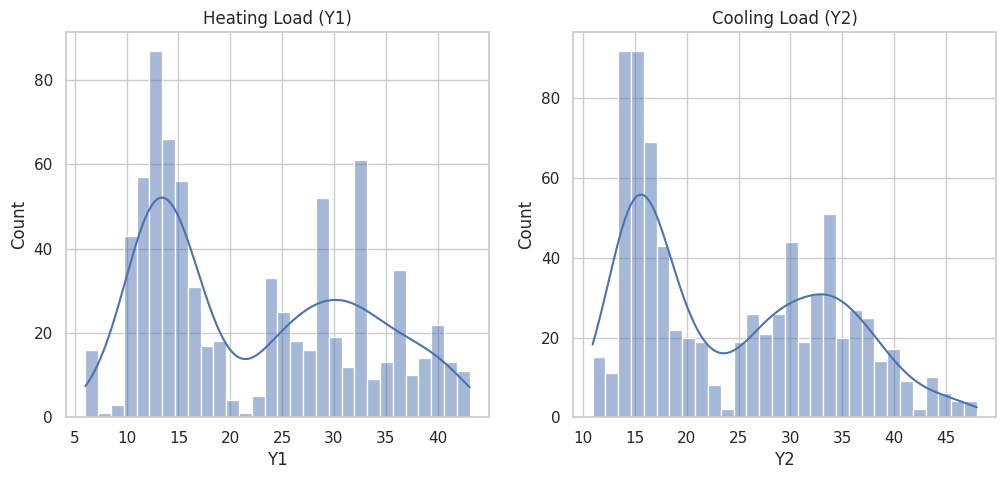

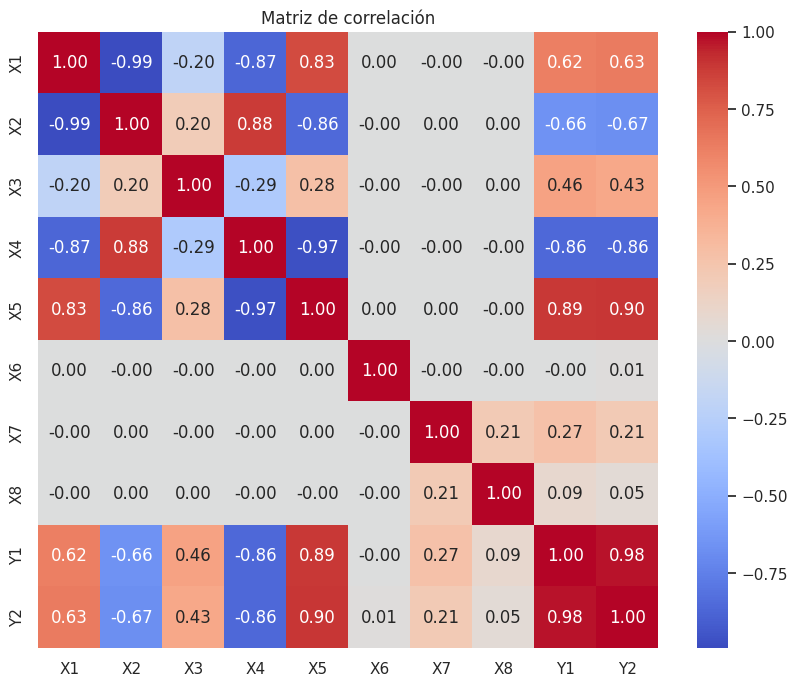

In [47]:
# Estadísticas básicas
print("\nEstadísticas descriptivas:")
print(energy_df.describe())

# Verificar si hay valores faltantes
print("\nValores faltantes por columna:")
print(energy_df.isna().sum())

# Correlaciones (enfocadas en Y1 y Y2)
print("\nCorrelaciones con Y1 y Y2:")
print(energy_df.corr(numeric_only=True)[["Y1","Y2"]].round(3))

# Histogramas de Y1 y Y2
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(energy_df["Y1"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Heating Load (Y1)")
sns.histplot(energy_df["Y2"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Cooling Load (Y2)")
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(energy_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [39]:
# 4.1 Separar features y targets
X = energy_df.drop(columns=["Y1","Y2"])
y1 = energy_df["Y1"]
y2 = energy_df["Y2"]

# 4.2 Codificar X6 y X8 (categóricas) con one‑hot
X_enc = pd.get_dummies(X, columns=["X6","X8"], drop_first=True)

# 4.3 Train/test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = \
    train_test_split(
        X_enc, y1, y2,
        test_size=0.2,
        random_state=42
    )

# 4.4 Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)

X_train_scaled shape: (614, 14)


In [40]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RF": RandomForestRegressor(n_estimators=300, random_state=42),
    "GBR": GradientBoostingRegressor(random_state=42)
}

In [41]:
results_y1 = []

for name, model in models.items():
    model.fit(X_train_scaled, y1_train)
    y1_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y1_test, y1_pred)
    rmse = np.sqrt(mean_squared_error(y1_test, y1_pred))
    r2 = r2_score(y1_test, y1_pred)
    results_y1.append((name, mae, rmse, r2))

df_results_y1 = pd.DataFrame(results_y1, columns=["Model","MAE","RMSE","R2"])
print("\n--- Resultados Y1 (Heating Load) ---")
print(df_results_y1)


--- Resultados Y1 (Heating Load) ---
    Model       MAE      RMSE        R2
0  Linear  2.059036  2.872277  0.920850
1   Ridge  2.074454  2.885487  0.920120
2   Lasso  2.061131  2.874030  0.920754
3      RF  0.360122  0.528048  0.997325
4     GBR  0.366965  0.503039  0.997572


In [42]:
results_y2 = []

for name, model in models.items():
    model.fit(X_train_scaled, y2_train)
    y2_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y2_test, y2_pred)
    rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))
    r2 = r2_score(y2_test, y2_pred)
    results_y2.append((name, mae, rmse, r2))

df_results_y2 = pd.DataFrame(results_y2, columns=["Model","MAE","RMSE","R2"])
print("\n--- Resultados Y2 (Cooling Load) ---")
print(df_results_y2)


--- Resultados Y2 (Cooling Load) ---
    Model       MAE      RMSE        R2
0  Linear  2.180512  3.119755  0.894958
1   Ridge  2.184942  3.128349  0.894379
2   Lasso  2.179475  3.120589  0.894902
3      RF  1.268449  2.035620  0.955279
4     GBR  1.079305  1.569259  0.973423


In [43]:
# Mejor modelo para Y1 (mínimo RMSE)
best_idx_y1 = df_results_y1["RMSE"].idxmin()
best_name_y1 = df_results_y1.loc[best_idx_y1, "Model"]
best_model_y1 = models[best_name_y1]

print(f"Mejor modelo Y1: {best_name_y1}")

# Mejor modelo para Y2
best_idx_y2 = df_results_y2["RMSE"].idxmin()
best_name_y2 = df_results_y2.loc[best_idx_y2, "Model"]
best_model_y2 = models[best_name_y2]

print(f"Mejor modelo Y2: {best_name_y2}")

Mejor modelo Y1: GBR
Mejor modelo Y2: GBR


In [44]:
# Cross‑validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_y1 = cross_val_score(
    best_model_y1,
    X_train_scaled,
    y1_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print(f"CV RMSE Y1 (mean ± std): {-cv_scores_y1.mean():.4f} ± {cv_scores_y1.std():.4f}")

CV RMSE Y1 (mean ± std): 0.4938 ± 0.0381



Top 10 features (Y1):
   Feature  Importance_Y1
1       X2       0.529338
3       X4       0.178257
0       X1       0.097572
4       X5       0.089139
2       X3       0.050296
5       X7       0.049692
7     X6_4       0.001452
8     X6_5       0.000995
6     X6_3       0.000914
11    X8_3       0.000804


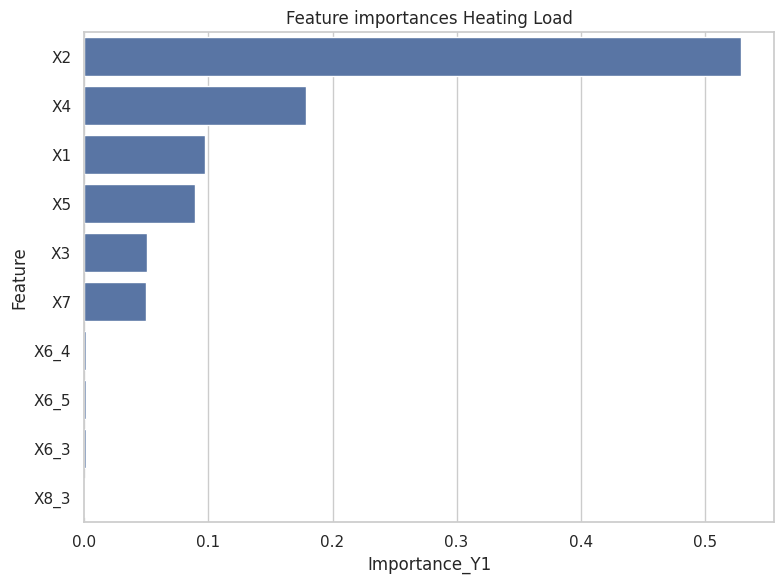

In [45]:
# Si el mejor modelo es RF o GBR, muestra importancias
if isinstance(best_model_y1, (RandomForestRegressor, GradientBoostingRegressor)):
    feat_imp_y1 = pd.DataFrame({
        "Feature": X_enc.columns,
        "Importance_Y1": best_model_y1.feature_importances_
    }).sort_values("Importance_Y1", ascending=False)

    print("\nTop 10 features (Y1):")
    print(feat_imp_y1.head(10))

    plt.figure(figsize=(8,6))
    sns.barplot(data=feat_imp_y1.head(10), x="Importance_Y1", y="Feature")
    plt.title("Feature importances Heating Load")
    plt.tight_layout()
    plt.show()

In [46]:
# Nuevo registro (ajusta valores según tu contexto)
nuevo = pd.DataFrame([{
    "X1": 0.90,
    "X2": 500.0,
    "X3": 300.0,
    "X4": 220.0,
    "X5": 7.0,
    "X6": 2,
    "X7": 0.25,
    "X8": 3
}])

# Aplicar mismo one‑hot encoding que en X_enc
nuevo_enc = pd.get_dummies(nuevo, columns=["X6","X8"])
nuevo_enc = nuevo_enc.reindex(columns=X_enc.columns, fill_value=0)

# Escalar
nuevo_scaled = scaler.transform(nuevo_enc)

# Predicciones
y1_nuevo = best_model_y1.predict(nuevo_scaled)
y2_nuevo = best_model_y2.predict(nuevo_scaled)

print(f"Heating Load (Y1) predicho: {y1_nuevo[0]:.2f}")
print(f"Cooling Load (Y2) predicho: {y2_nuevo[0]:.2f}")

Heating Load (Y1) predicho: 27.42
Cooling Load (Y2) predicho: 27.42


## CLASIFICACION

In [50]:
student_df_1 = pd.read_csv('student-por.csv', sep=';')
student_df_2 = pd.read_csv('student-mat.csv', sep=';')

student_df = pd.concat([student_df_1, student_df_2], ignore_index=True)
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [56]:
student_num = student_df.select_dtypes(include="number")
correlation_matrix = student_num.corr()
correlation_with_G3 = correlation_matrix["G3"].sort_values(ascending=False)
print(correlation_with_G3)

G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


In [57]:
student_df.head().describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,5.00000,5.000000,5.00000,5.000000,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000
mean,16.20000,2.600000,2.20000,1.200000,2.200000,0.0,4.000000,2.800000,2.600000,1.200000,1.600000,3.800000,2.400000,9.200000,12.400000,12.20000
std,1.30384,1.516575,1.30384,0.447214,0.447214,0.0,0.707107,0.447214,0.894427,0.447214,0.894427,1.095445,2.607681,5.449771,1.341641,1.30384
min,15.00000,1.000000,1.00000,1.000000,2.000000,0.0,3.000000,2.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,11.000000,11.00000
25%,15.00000,1.000000,1.00000,1.000000,2.000000,0.0,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,11.000000,11.00000
50%,16.00000,3.000000,2.00000,1.000000,2.000000,0.0,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,2.000000,11.000000,13.000000,12.00000
75%,17.00000,4.000000,3.00000,1.000000,2.000000,0.0,4.000000,3.000000,3.000000,1.000000,2.000000,5.000000,4.000000,12.000000,13.000000,13.00000
max,18.00000,4.000000,4.00000,2.000000,3.000000,0.0,5.000000,3.000000,4.000000,2.000000,3.000000,5.000000,6.000000,14.000000,14.000000,14.00000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

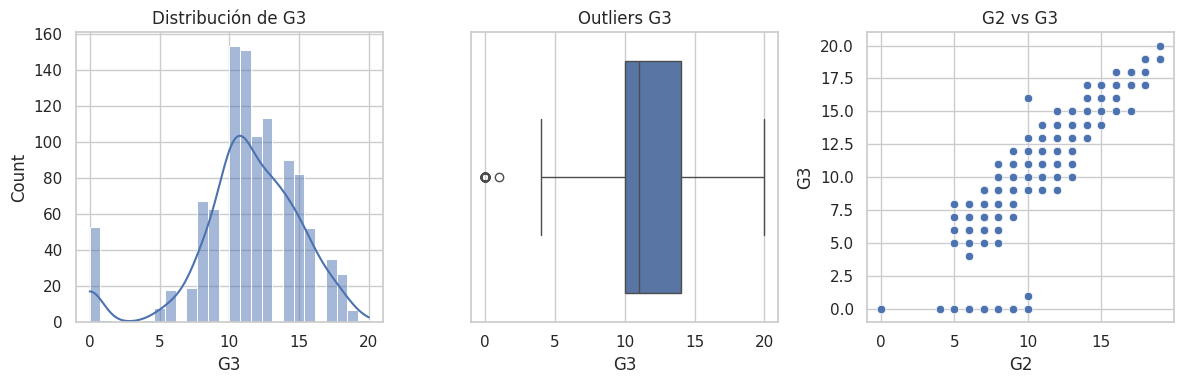

In [64]:
# 1.1. Info general
print(student_df.info())
print(student_df.describe())  # estadísticas descriptivas de numéricas

# 1.1. crear variable binaria: aprueba (G3 >= 10) vs suspenso
student_df["passed"] = (student_df["G3"] >= 10).astype(int)  # 1 = aprueba, 0 = suspenso

# 1.2. separar variables
target = "passed"
X = student_df.drop(columns=["G3", "passed"], axis=1)  # usa todas las demás
y = student_df[target]

# 1.2. tipos de datos
print("Categóricas:")
print(student_df.select_dtypes(include="object").columns.tolist())

print("\nNuméricas:")
print(student_df.select_dtypes(include="number").columns.tolist())

# 1.3. ver nulos (aunque tu info dice 1044 non-null en todas)
print("\nValores nulos por columna:")
print(student_df.isnull().sum())

# 1.4. visualizaciones básicas (ejemplo: G3)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(student_df["G3"], kde=True)
plt.title("Distribución de G3")

plt.subplot(1, 3, 2)
sns.boxplot(x=student_df["G3"])
plt.title("Outliers G3")

plt.subplot(1, 3, 3)
sns.scatterplot(x=student_df["G2"], y=student_df["G3"])
plt.title("G2 vs G3")

plt.tight_layout()
plt.show()

In [65]:
# 2. PREPROCESAMIENTO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # estratificado por clase
)

# 2.1. identificar tipos
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

# 2.2. pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

In [68]:
# 3. MODELOS DE CLASIFICACIÓN
models = [
    ("Logistic", LogisticRegression(random_state=42)),
    ("RF", RandomForestClassifier(random_state=42, n_estimators=100)),
    ("GBR", GradientBoostingClassifier(random_state=42)),
]

In [69]:
# 4. ENTRENAR Y EVALUAR
print("Modelo     |  Acc   |  Prec  |  Rec   |   F1   |  AUC  ")
print("-" * 57)

for name, model in models:
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"{name:10s} | {acc:6.3f} | {prec:6.3f} | {rec:6.3f} | {f1:6.3f} | {auc:5.3f}")

    # reporte detallado del mejor modelo (por ejemplo RF)
    if name == "RF":
        print(f"\n### Clasificación Report - {name}:\n")
        print(classification_report(y_test, y_pred))


Modelo     |  Acc   |  Prec  |  Rec   |   F1   |  AUC  
---------------------------------------------------------
Logistic   |  0.914 |  0.939 |  0.951 |  0.945 | 0.962
RF         |  0.900 |  0.923 |  0.951 |  0.937 | 0.961

### Clasificación Report - RF:

              precision    recall  f1-score   support

           0       0.80      0.72      0.76        46
           1       0.92      0.95      0.94       163

    accuracy                           0.90       209
   macro avg       0.86      0.83      0.85       209
weighted avg       0.90      0.90      0.90       209

GBR        |  0.904 |  0.933 |  0.945 |  0.939 | 0.952


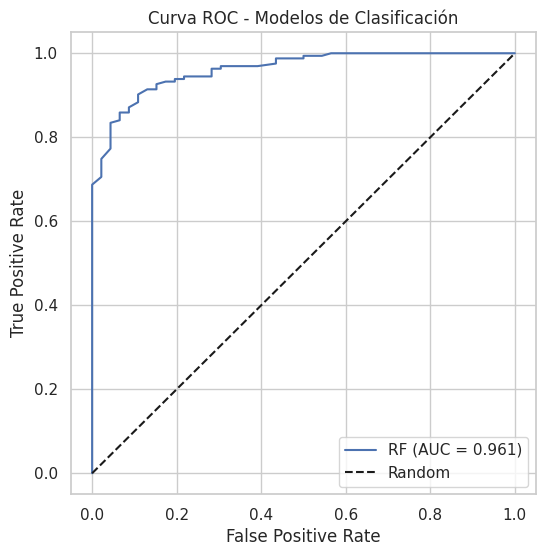

In [70]:
# 5. CURVA ROC DEL MEJOR MODELO (ej. RF)
pipe_best = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])
pipe_best.fit(X_train, y_train)
y_pred_proba_best = pipe_best.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF (AUC = {auc_best:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelos de Clasificación")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
# 6. PREDICCIÓN CON NUEVOS DATOS
# ejemplo de un nuevo estudiante
new_student = pd.DataFrame([{
    "school": "GP",
    "sex": "F",
    "age": 16,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 4,
    "Fedu": 4,
    "Mjob": "other",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 2,
    "failures": 0,
    "schoolsup": "no",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 2,
    "Dalc": 1,
    "Walc": 1,
    "health": 5,
    "absences": 4,
    "G1": 12,
    "G2": 13,
}])

# 6.1. predecir clase y probabilidad
pred = pipe_best.predict(new_student)[0]
prob = pipe_best.predict_proba(new_student)[0, 1]

print("\nPredicción para nuevo estudiante:")
print(" - Clase predicha:", "Aprueba" if pred == 1 else "Reprueba")
print(" - Probabilidad de aprobar:", f"{prob:.3f}")


Predicción para nuevo estudiante:
 - Clase predicha: Aprueba
 - Probabilidad de aprobar: 1.000
